In [1]:
import numpy as np
import pandas as pd
import scanpy as sc
import anndata as ad
import matplotlib.pyplot as plt

from pathlib import Path

from scipy.io import mmread

import gtra

%load_ext autoreload
%autoreload 2

In [14]:
SIM_PATH = Path("/home/jyj/docker_dat/GTra_pro/dyngen_python_export2")

In [16]:
counts = pd.read_csv(SIM_PATH / "counts.csv", index_col=0)
cells = pd.read_csv(SIM_PATH / "cell_info.csv", index_col=0)
features = pd.read_csv(SIM_PATH / "feature_info.csv", index_col=0)

In [17]:
adata = ad.AnnData(X=counts.values, obs=cells, var=features)

In [18]:


gtra_obj = gtra.GTraObject()

gtra_obj.params.cell_type_label = "milestone_id"
gtra_obj.params.output_dir = "./dyngen_simulation"
gtra_obj.params.output_name = "dyngen_simulation"
gtra_obj.params.cn_cluster_resolution = 0.3

# Upload time-series scRNA_seq data
for time in sorted(adata.obs["timepoint"].unique()):
    dat = adata[adata.obs["timepoint"]==time]
    cnt_dat = dat.to_df()
    meta = dat.obs[[gtra_obj.params.cell_type_label]]
    # print(meta['dominant_milestone'].value_counts())
    gtra_obj.upload_time_scRNA(cnt_dat, meta)

# gtra_obj.select_genes()

### Run GTra

In [19]:
gtra_obj.find_gclusters()

Step 1: Identifying cell type-specific gene clusters...


In [20]:
gtra_obj.construct_trajectories()

Step 2: Constructing cell-state trajectories..: 100%|=================| 3/3 [00:01<00:00,  1.76it/s]


Step 3: Detecting time-series pattern clustering...: 100%|============| 5/5 [00:00<00:00, 33.36it/s]


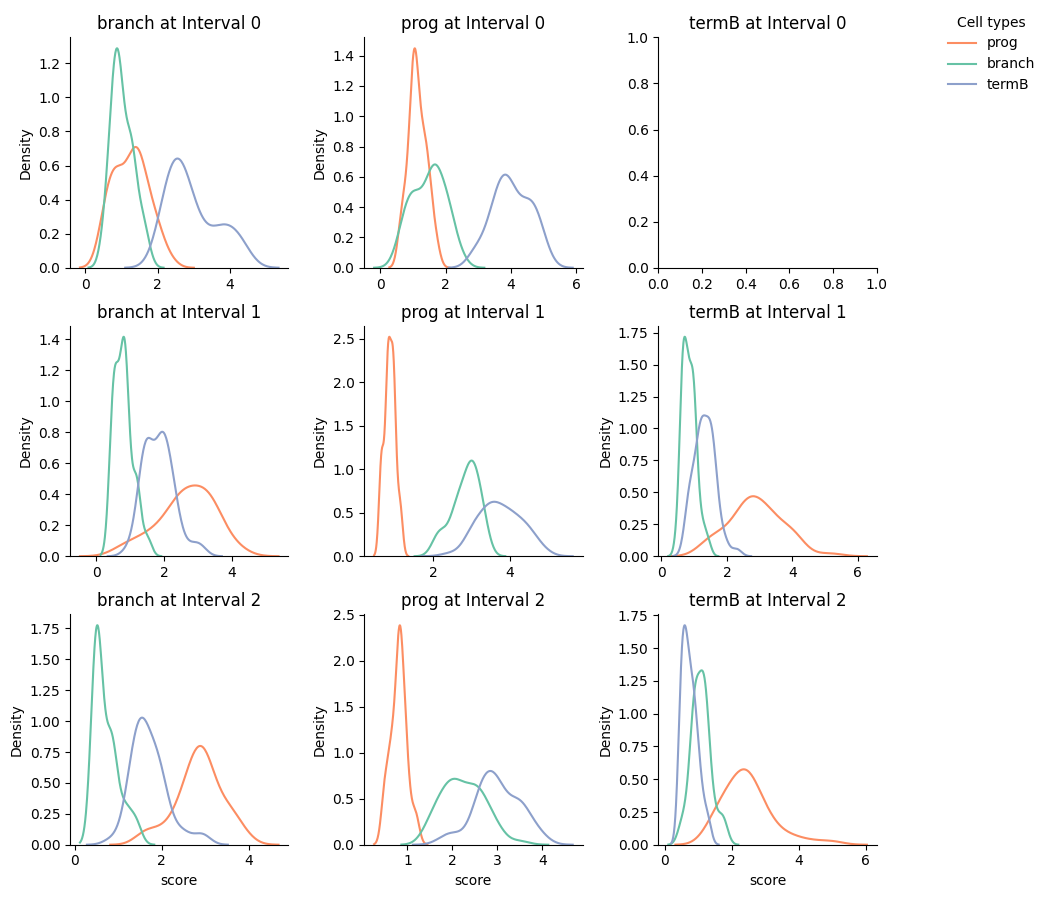

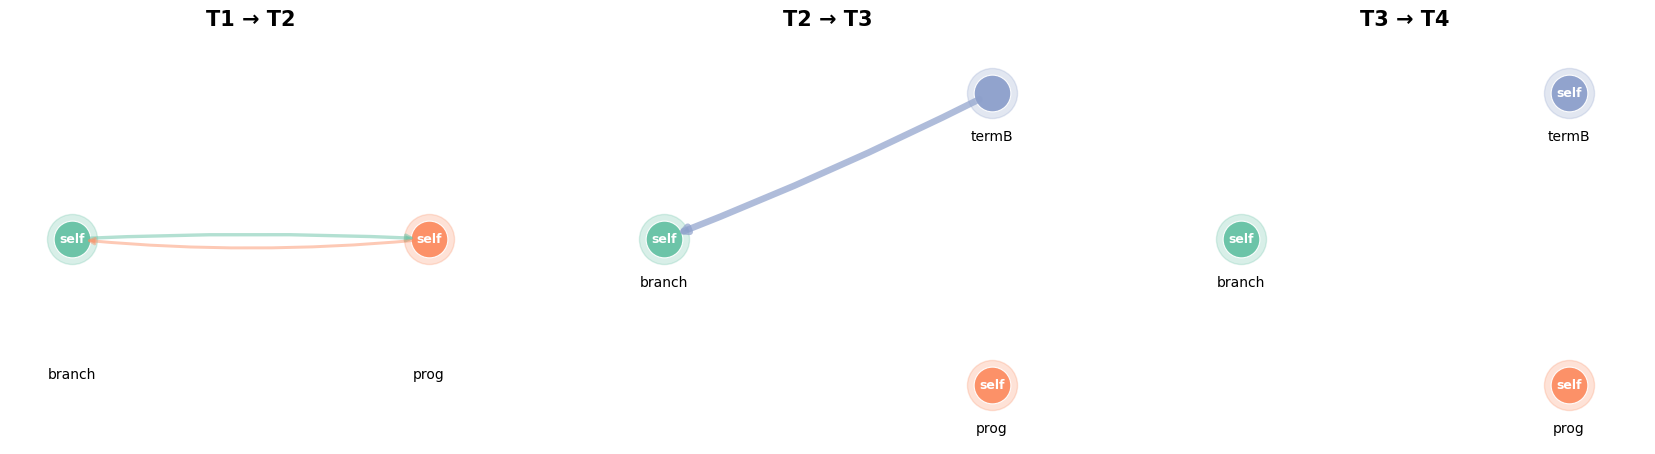

Plotting time-series gene expression patterns...


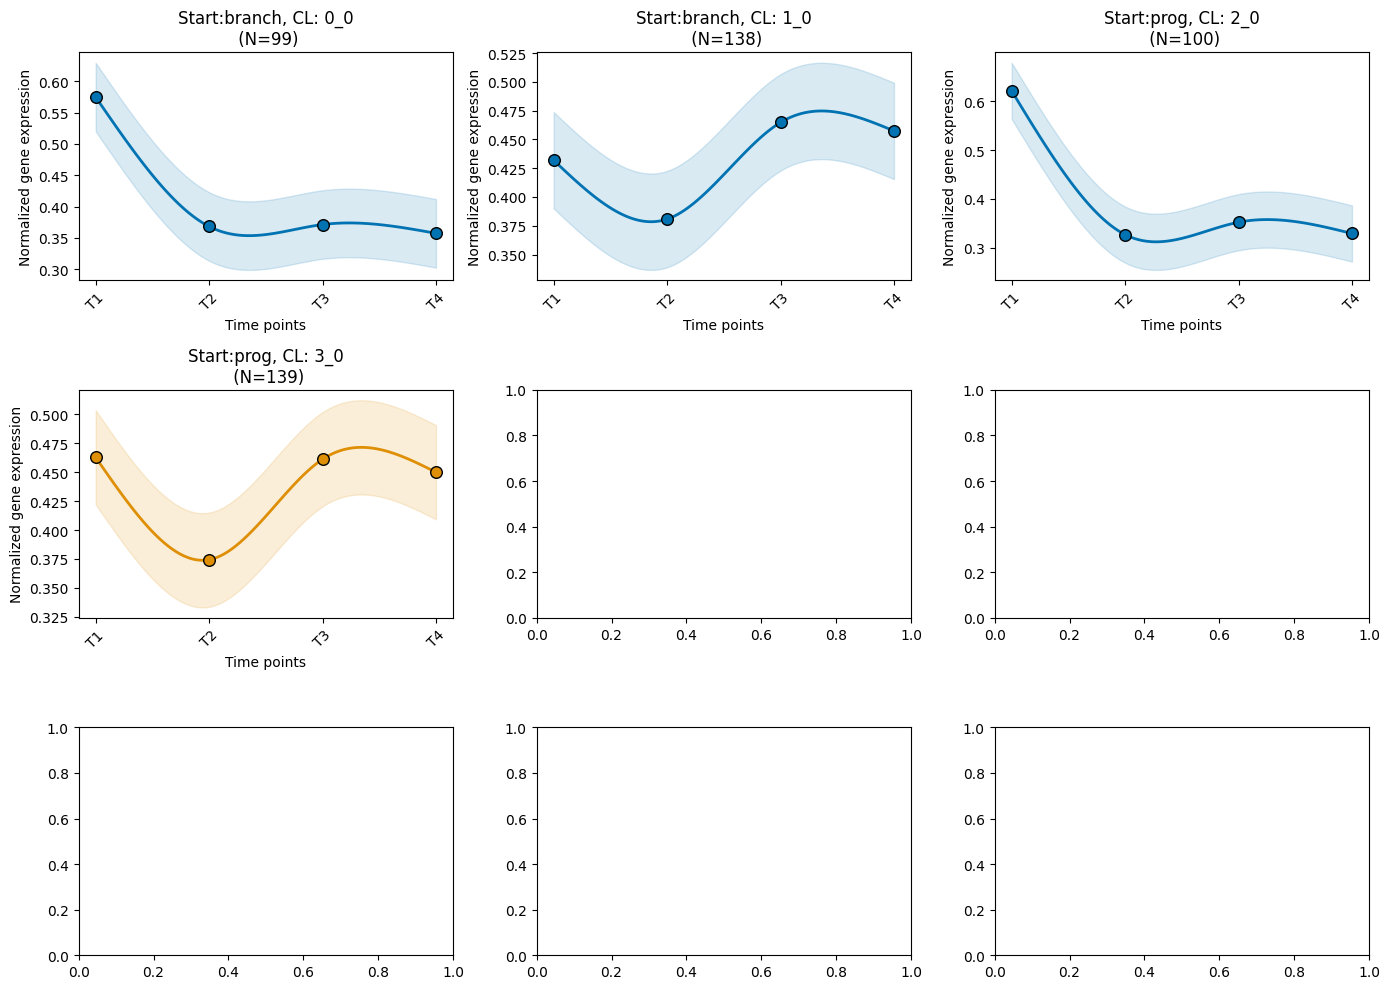

In [21]:
gtra_obj.pattern_clustering()
gtra_obj.params.time_point_label = ["T1", "T2", "T3","T4"]
gtra_obj.plot_edge_statistic()
gtra_obj.plot_cell_state_graph()
gtra_obj.plot_patterns()